In [1]:
!pip install -q transformers datasets sentencepiece accelerate pandas textstat rouge-score bert-score sacrebleu matplotlib

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 65.8 MB/s eta 0:00:00


In [2]:
import gc
import torch
import pandas as pd
import matplotlib.pyplot as plt

from textstat import flesch_kincaid_grade, automated_readability_index
from rouge_score import rouge_scorer
from bert_score import score as bertscore_score

# Model card uses T5Tokenizer + T5ForConditionalGeneration.
# AutoModelForSeq2SeqLM also works but T5-specific classes are preferred per the card.
from transformers import T5Tokenizer, T5ForConditionalGeneration

In [3]:
# NOTE: google/flan-t5-large is a public model — no HuggingFace token required.

# Change this if your file name is different
DATA_PATH = "/content/pilot_20_baseline_eval.csv"

df = pd.read_csv(DATA_PATH)

print("Columns found:")
print(df.columns.tolist())
print("\nNumber of rows:", len(df))

df.head()

Columns found:
['example_id', 'act_name', 'section_id', 'unit_label', 'unit_type', 'page_start', 'source_text', 'has_modal', 'has_exception', 'has_numbers', 'has_roles', 'needs_context', 'bad_fragment', 'simple_text', 'split', 'notes', 'pilot_category', 'llama3.2_output', 'qwen3_output', 'mistral_output', 'gemma_output', 'flan_t5_output', 'bart_output']

Number of rows: 20


,example_id,act_name,section_id,unit_label,unit_type,page_start,source_text,has_modal,has_exception,has_numbers,...,simple_text,split,notes,pilot_category,llama3.2_output,qwen3_output,mistral_output,gemma_output,flan_t5_output,bart_output
0,SL00023,Penal Code,Section 22,NaN,section_body,NaN,Whoever does anything with the intention of ca...,0,0,1,...,A person acts dishonestly if they intend to ca...,train,NaN,definition,NaN,NaN,NaN,NaN,NaN,NaN
1,SL00135,Penal Code,Section 100,explanation,explanation,30.0,A person who. by willful misrepresentation or ...,0,0,1,...,A person instigates an act if they deliberatel...,train,NaN,definition,NaN,NaN,NaN,NaN,NaN,NaN
2,SL00022,Penal Code,Section 20,4,subsection,8.0,A person is said to lose wrongfully when such...,0,0,1,...,A person does not only lose property wrongfull...,train,NaN,definition,NaN,NaN,NaN,NaN,NaN,NaN
3,SL00045,Penal Code,Section 35,NaN,section_body,11.0,When an offence is committed by means of sever...,0,0,1,...,f a crime is carried out through a series of s...,train,NaN,definition,NaN,NaN,NaN,NaN,NaN,NaN
4,SL00049,Penal Code,Section 37,NaN,section_body,NaN,A person is said to cause an effect 'voluntari...,0,0,1,...,A person acts voluntarily if they meant to bri...,train,NaN,definition,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Required input columns
required_columns = ["source_text", "simple_text"]

missing = [col for col in required_columns if col not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("Input CSV is valid.")

Input CSV is valid.


In [5]:
MODEL_NAME = "google/flan-t5-large"
MODEL_LABEL = "FLAN-T5-Large"

OUTPUT_COLUMN = "flan_t5_output"
FKGL_COLUMN = "flan_t5_fkgl"
ARI_COLUMN = "flan_t5_ari"
ROUGE_COLUMN = "flan_t5_rougeL"
BERTSCORE_COLUMN = "flan_t5_bertscore_f1"

In [6]:
# Create model-specific output columns if they don't already exist
columns_to_create = [
    OUTPUT_COLUMN,
    FKGL_COLUMN,
    ARI_COLUMN,
    ROUGE_COLUMN,
    BERTSCORE_COLUMN
]

for col in columns_to_create:
    if col not in df.columns:
        df[col] = None

print("Model-specific columns are ready.")

Model-specific columns are ready.


In [7]:
# Model card preferred classes: T5Tokenizer + T5ForConditionalGeneration
# Training sequence lengths per paper: 1024 input / 256 output tokens
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
model = T5ForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

print("Model loaded.")
print("CUDA available:", torch.cuda.is_available())

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model loaded.
CUDA available: True


In [8]:
def build_prompt(source_text: str) -> str:
    return f"""Simplify the following Sri Lankan legal provision into plain English.
Preserve the legal meaning as closely as possible.
Preserve SHALL, MAY, SHALL NOT, conditions, exceptions, numbers, punishments, fines, dates, ages, thresholds, and legal roles.
Do not add examples, explanations, or legal advice.
Rewrite the provision so it is easier to read.

Provision:
{source_text}

Simplified:"""

In [9]:
def generate_output(source_text: str) -> str:
    prompt = build_prompt(source_text)

    # FLAN-T5 was trained with 1024 input / 256 output token windows.
    # max_length=1024 here is correct — it covers prompt + source text combined.
    # The instruction prompt uses ~68 tokens, leaving ~956 for the legal provision.
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,
            num_beams=4,
            early_stopping=True
        )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return text.strip()

In [10]:
# Test on 2 rows first
for i in range(min(2, len(df))):
    source = str(df.loc[i, "source_text"])
    gold = str(df.loc[i, "simple_text"]) if pd.notna(df.loc[i, "simple_text"]) else ""

    pred = generate_output(source)

    print("ROW:", i)
    print("\nSOURCE:\n", source)
    print("\nGOLD SIMPLE TEXT:\n", gold)
    print("\nMODEL OUTPUT:\n", pred)
    print("\n" + "=" * 100 + "\n")

ROW: 0

SOURCE:
 Whoever does anything with the intention of causing wrongful gain to one person, or wrongful loss to another person, is said to do that thing ' dishonestly '.

GOLD SIMPLE TEXT:
 A person acts dishonestly if they intend to cause wrongful gain to one person or wrongful loss to another.

MODEL OUTPUT:
 Whoever does anything with the intention of causing wrongful gain to one person, or wrongful loss to another person, is said to do that thing ' dishonestly '.


ROW: 1

SOURCE:
 A person who. by willful misrepresentation or by willful concealment of a material fact which he is bound to disclose, voluntarily causes or procures, or attempts to cause or procure, a thing to be done, is said to instigate the doing of that thing.

GOLD SIMPLE TEXT:
 A person instigates an act if they deliberately lie or hide an important fact they had a duty to disclose, and this causes or tries to cause another person to do that act.

MODEL OUTPUT:
 A person who. by willful misrepresentation or

In [11]:
# Run the model on all rows
outputs = []

for i, text in enumerate(df["source_text"].fillna("").astype(str).tolist(), start=1):
    pred = generate_output(text)
    outputs.append(pred)
    print(f"Done {i}/{len(df)}")

df[OUTPUT_COLUMN] = outputs
print("Generation complete.")

Done 1/20
Done 2/20
Done 3/20
Done 4/20
Done 5/20
Done 6/20
Done 7/20
Done 8/20
Done 9/20
Done 10/20
Done 11/20
Done 12/20
Done 13/20
Done 14/20
Done 15/20
Done 16/20
Done 17/20
Done 18/20
Done 19/20
Done 20/20
Generation complete.


In [12]:
def safe_fkgl(text):
    text = str(text).strip()
    if not text:
        return None
    try:
        return float(flesch_kincaid_grade(text))
    except Exception:
        return None

def safe_ari(text):
    text = str(text).strip()
    if not text:
        return None
    try:
        return float(automated_readability_index(text))
    except Exception:
        return None

df[FKGL_COLUMN] = df[OUTPUT_COLUMN].apply(safe_fkgl)
df[ARI_COLUMN] = df[OUTPUT_COLUMN].apply(safe_ari)

df[[OUTPUT_COLUMN, FKGL_COLUMN, ARI_COLUMN]].head()

,flan_t5_output,flan_t5_fkgl,flan_t5_ari
0,Whoever does anything with the intention of ca...,13.611538,13.606071
1,A person who. by willful misrepresentation or ...,11.494545,11.514318
2,A person is said to lose wrongfully when such ...,9.087059,8.126471
3,When an offence is committed by means of sever...,18.931892,21.001892
4,A person is said to cause an effect 'voluntari...,17.693333,20.014667


In [13]:
# ROUGE-L against human gold simplification
scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

rouge_scores = []

for pred, ref in zip(df[OUTPUT_COLUMN].fillna("").astype(str), df["simple_text"].fillna("").astype(str)):
    pred = pred.strip()
    ref = ref.strip()

    if not pred or not ref:
        rouge_scores.append(None)
    else:
        score = scorer.score(ref, pred)
        rouge_scores.append(float(score["rougeL"].fmeasure))

df[ROUGE_COLUMN] = rouge_scores

df[[OUTPUT_COLUMN, "simple_text", ROUGE_COLUMN]].head()

,flan_t5_output,simple_text,flan_t5_rougeL
0,Whoever does anything with the intention of ca...,A person acts dishonestly if they intend to ca...,0.488889
1,A person who. by willful misrepresentation or ...,A person instigates an act if they deliberatel...,0.337662
2,A person is said to lose wrongfully when such ...,A person does not only lose property wrongfull...,0.320000
3,When an offence is committed by means of sever...,f a crime is carried out through a series of s...,0.309859
4,A person is said to cause an effect 'voluntari...,A person acts voluntarily if they meant to bri...,0.361446


In [14]:
# BERTScore against human gold simplification
preds = df[OUTPUT_COLUMN].fillna("").astype(str).tolist()
refs = df["simple_text"].fillna("").astype(str).tolist()

valid_indices = []
valid_preds = []
valid_refs = []

for i, (pred, ref) in enumerate(zip(preds, refs)):
    if pred.strip() and ref.strip():
        valid_indices.append(i)
        valid_preds.append(pred)
        valid_refs.append(ref)

bert_f1_scores = [None] * len(df)

if valid_preds:
    P, R, F1 = bertscore_score(valid_preds, valid_refs, lang="en", verbose=False)
    for idx, score in zip(valid_indices, F1):
        bert_f1_scores[idx] = float(score)

df[BERTSCORE_COLUMN] = bert_f1_scores

df[[OUTPUT_COLUMN, "simple_text", BERTSCORE_COLUMN]].head()

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,flan_t5_output,simple_text,flan_t5_bertscore_f1
0,Whoever does anything with the intention of ca...,A person acts dishonestly if they intend to ca...,0.923808
1,A person who. by willful misrepresentation or ...,A person instigates an act if they deliberatel...,0.889001
2,A person is said to lose wrongfully when such ...,A person does not only lose property wrongfull...,0.896293
3,When an offence is committed by means of sever...,f a crime is carried out through a series of s...,0.916503
4,A person is said to cause an effect 'voluntari...,A person acts voluntarily if they meant to bri...,0.914225


In [15]:
# Create a clean result table without dataset-analysis metadata columns
keep_cols = []

# Keep useful identifiers only if they exist
for col in ["example_id", "act_name", "section_id", "unit_type", "split"]:
    if col in df.columns:
        keep_cols.append(col)

keep_cols += [
    "source_text",
    "simple_text",
    OUTPUT_COLUMN,
    FKGL_COLUMN,
    ARI_COLUMN,
    ROUGE_COLUMN,
    BERTSCORE_COLUMN
]

result_df = df[keep_cols].copy()

print("Clean result table preview:")
result_df.head(10)

Clean result table preview:


,example_id,act_name,section_id,unit_type,split,source_text,simple_text,flan_t5_output,flan_t5_fkgl,flan_t5_ari,flan_t5_rougeL,flan_t5_bertscore_f1
0,SL00023,Penal Code,Section 22,section_body,train,Whoever does anything with the intention of ca...,A person acts dishonestly if they intend to ca...,Whoever does anything with the intention of ca...,13.611538,13.606071,0.488889,0.923808
1,SL00135,Penal Code,Section 100,explanation,train,A person who. by willful misrepresentation or ...,A person instigates an act if they deliberatel...,A person who. by willful misrepresentation or ...,11.494545,11.514318,0.337662,0.889001
2,SL00022,Penal Code,Section 20,subsection,train,A person is said to lose wrongfully when such...,A person does not only lose property wrongfull...,A person is said to lose wrongfully when such ...,9.087059,8.126471,0.320000,0.896293
3,SL00045,Penal Code,Section 35,section_body,train,When an offence is committed by means of sever...,f a crime is carried out through a series of s...,When an offence is committed by means of sever...,18.931892,21.001892,0.309859,0.916503
4,SL00049,Penal Code,Section 37,section_body,train,A person is said to cause an effect 'voluntari...,A person acts voluntarily if they meant to bri...,A person is said to cause an effect 'voluntari...,17.693333,20.014667,0.361446,0.914225
5,SL00073,Penal Code,Section 54,section_body,train,Sentence of death shall not be pronounced on o...,A pregnant woman cannot be sentenced to death....,Sentence of death shall not be pronounced on o...,13.629032,15.189032,0.450000,0.920076
6,SL00075,Penal Code,Section 56,section_body,train,In every case in which a person is convicted o...,If someone is convicted of a crime where all t...,In every case in which a person is convicted o...,28.272063,32.423810,0.218487,0.881930
7,SL00077,Penal Code,Section 57,section_body,train,No female shall in any case be punished with w...,Women cannot be punished by whipping under any...,No female shall be punished with whipping. Nor...,6.340862,7.908276,0.576271,0.934896
8,SL00160,Penal Code,Section 107,section_body,train,"Whenever any person who, if absent, would be l...",If a person encouraged or helped someone commi...,"Whenever any person who, if absent, would be l...",19.280435,22.560217,0.097561,0.860987
9,SL00166,Penal Code,Section 110,section_body,train,Whoever abets the commission of an offence by ...,If a person encourages or helps a crime that i...,Whoever abets the commission of an offence by ...,19.017209,22.196047,0.352941,0.898404


In [16]:
def avg_of_column(dataframe, col_name):
    vals = pd.to_numeric(dataframe[col_name], errors="coerce")
    vals = vals.dropna()
    return None if len(vals) == 0 else round(float(vals.mean()), 3)

summary = {
    "Model": MODEL_LABEL,
    "Rows": len(result_df),
    "Avg FKGL": avg_of_column(result_df, FKGL_COLUMN),
    "Avg ARI": avg_of_column(result_df, ARI_COLUMN),
    "Avg ROUGE-L": avg_of_column(result_df, ROUGE_COLUMN),
    "Avg BERTScore F1": avg_of_column(result_df, BERTSCORE_COLUMN),
}

summary_df = pd.DataFrame([summary])
summary_df

,Model,Rows,Avg FKGL,Avg ARI,Avg ROUGE-L,Avg BERTScore F1
0,FLAN-T5-Large,20,22.484,26.009,0.333,0.897


In [17]:
# Save clean CSV
OUT_PATH = "/content/pilot_20_baseline_eval_with_flan_t5_checked_clean.csv"
result_df.to_csv(OUT_PATH, index=False)

print(f"Saved clean result CSV to: {OUT_PATH}")

Saved clean result CSV to: /content/pilot_20_baseline_eval_with_flan_t5_checked_clean.csv


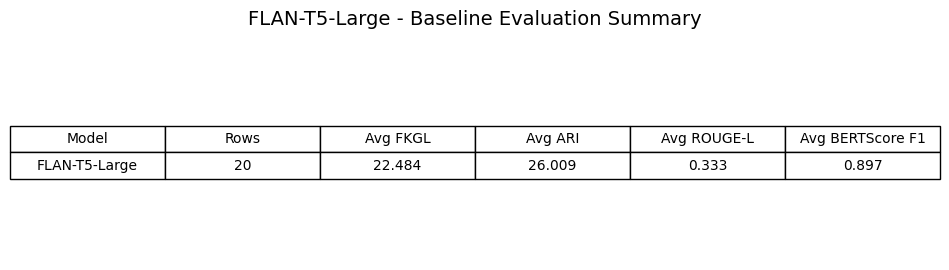

Saved summary table image to: /content/flan_t5_summary_table.png


In [18]:
# Create summary table image for screenshot/report
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.axis("off")

plt.title(f"{MODEL_LABEL} - Baseline Evaluation Summary", fontsize=14, pad=14)

table = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)

IMAGE_PATH = "/content/flan_t5_summary_table.png"
plt.savefig(IMAGE_PATH, bbox_inches="tight", dpi=200)
plt.show()

print(f"Saved summary table image to: {IMAGE_PATH}")

In [19]:
del model
del tokenizer
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Memory cleared.")

Memory cleared.
